In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

# Load dataset
data = load_iris()
X = data.data
y = data.target
feature_names = data.feature_names

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.decomposition import PCA

# Reduce to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio (PCA):", pca.explained_variance_ratio_)

Explained Variance Ratio (PCA): [0.72962445 0.22850762]


In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# LDA (max components = classes - 1 = 2)
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

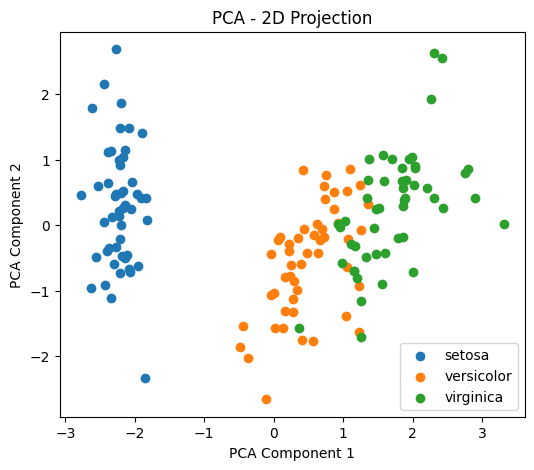

In [ ]:
plt.figure(figsize=(6,5))
for i in np.unique(y):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], label=data.target_names[i])

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA - 2D Projection")
plt.legend()
plt.show()

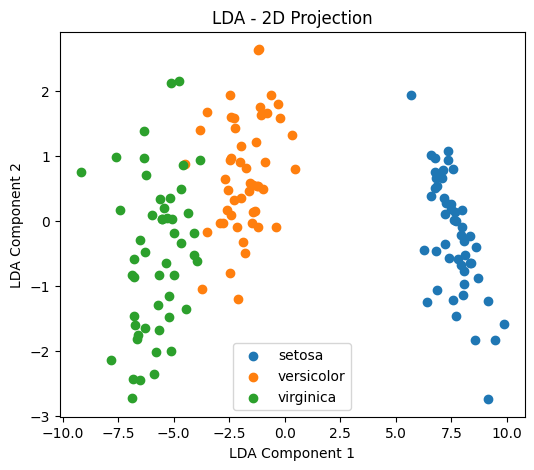

In [ ]:
plt.figure(figsize=(6,5))
for i in np.unique(y):
    plt.scatter(X_lda[y == i, 0], X_lda[y == i, 1], label=data.target_names[i])

plt.xlabel("LDA Component 1")
plt.ylabel("LDA Component 2")
plt.title("LDA - 2D Projection")
plt.legend()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Train-test split
X_train_pca, X_test_pca, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)
X_train_lda, X_test_lda, _, _ = train_test_split(X_lda, y, test_size=0.2, random_state=42)

# Model
model = LogisticRegression()

# PCA model
model.fit(X_train_pca, y_train)
y_pred_pca = model.predict(X_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)

# LDA model
model.fit(X_train_lda, y_train)
y_pred_lda = model.predict(X_test_lda)
acc_lda = accuracy_score(y_test, y_pred_lda)

print("Accuracy using PCA:", acc_pca)
print("Accuracy using LDA:", acc_lda)

Accuracy using PCA: 0.9
Accuracy using LDA: 1.0


In [ ]:
print("\n=== FINAL RESULT ===")
print("PCA Accuracy:", acc_pca)
print("LDA Accuracy:", acc_lda)

if acc_pca > acc_lda:
    print("PCA performs better")
elif acc_lda > acc_pca:
    print("LDA performs better")
else:
    print("Both perform equally")


=== FINAL RESULT ===
PCA Accuracy: 0.9
LDA Accuracy: 1.0
LDA performs better
